# Image Acquisition

Acquire a full-frame image, a cropped rectangle scan, and images from multiple detectors.


### Run the servers

Make sure you are on the VPN and the AutoScript server is running. Then start the asyncroscopy Tango servers from the repository root:

```bash
uv run startup_scripts/run_servers.py
```


### Imports


In [1]:
import os
import json
import tango
import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt
from tiled.client import from_uri

%matplotlib ipympl

### Ping servers


In [2]:
DB_HOST = "216.96.178.92"
# DB_HOST = "localhost"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"


scan = tango.DeviceProxy("asyncroscopy/scan/default")
camera = tango.DeviceProxy("asyncroscopy/camera/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    print(proxy)
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())


SCAN(asyncroscopy/scan/default)
asyncroscopy/scan/default ON
DigitalTwinDiffraction(asyncroscopy/instrument/default)
asyncroscopy/instrument/default ON
DATA(asyncroscopy/data/default)
asyncroscopy/data/default ON


In [3]:
seg = tango.DeviceProxy("asyncroscopy/segment/default")
seg.set_timeout_millis(240_000)

### Set Tiled Client


In [4]:
config = json.loads(data.get_config())
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: ['stem_image_HAADF_20260617T113100890911.h5', 'spectrum_eds_20260617T113333863968.h5', 'spectrum_eds_20260617T113333946998.h5', 'spectrum_eds_20260617T113334018225.h5', 'spectrum_eds_20260617T113334090072.h5', 'spectrum_eds_20260617T113334158870.h5', 'stem_image_HAADF_20260619T193537178014.h5', 'stem_image_HAADF_20260619T193629581856.h5', 'diffraction_BM-Ceta_20260619T193631500749.h5', 'diffraction_BM-Ceta_20260619T193631852562.h5', 'diffraction_BM-Ceta_20260619T193635044869.h5', 'diffraction_BM-Ceta_20260619T193638201360.h5', 'diffraction_BM-Ceta_20260619T193641355383.h5', 'stem_image_HAADF_20260619T193755955267.h5', 'stem_image_HAADF_20260619T194030676929.h5', 'stem_image_HAADF_20260619T194736076730.h5', 'stem_image_HAADF_20260619T195116284309.h5', 'stem_image_HAADF_20260619T195724455994.h5', 'diffraction_BM-Ceta_20260619T195742736439.h5', 'diffraction_BM-Ceta_20260619T195810018189.h5', 'diffraction_BM-Ceta_20260619T195848501752.h5', 'diffraction_BM-Ceta_20260619T19590691

In [5]:
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: ['stem_image_HAADF_20260617T113100890911.h5', 'spectrum_eds_20260617T113333863968.h5', 'spectrum_eds_20260617T113333946998.h5', 'spectrum_eds_20260617T113334018225.h5', 'spectrum_eds_20260617T113334090072.h5', 'spectrum_eds_20260617T113334158870.h5', 'stem_image_HAADF_20260619T193537178014.h5', 'stem_image_HAADF_20260619T193629581856.h5', 'diffraction_BM-Ceta_20260619T193631500749.h5', 'diffraction_BM-Ceta_20260619T193631852562.h5', 'diffraction_BM-Ceta_20260619T193635044869.h5', 'diffraction_BM-Ceta_20260619T193638201360.h5', 'diffraction_BM-Ceta_20260619T193641355383.h5', 'stem_image_HAADF_20260619T193755955267.h5', 'stem_image_HAADF_20260619T194030676929.h5', 'stem_image_HAADF_20260619T194736076730.h5', 'stem_image_HAADF_20260619T195116284309.h5', 'stem_image_HAADF_20260619T195724455994.h5', 'diffraction_BM-Ceta_20260619T195742736439.h5', 'diffraction_BM-Ceta_20260619T195810018189.h5', 'diffraction_BM-Ceta_20260619T195848501752.h5', 'diffraction_BM-Ceta_20260619T19590691

### Configure scan


In [6]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
scan.output_format = ".h5"

print("dwell_time :", scan.dwell_time)
print("image size :", scan.imsize)
print("scan region:", list(scan.scan_region))


dwell_time : 1e-06
image size : 512
scan region: [np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]


### Acquire a HAADF image


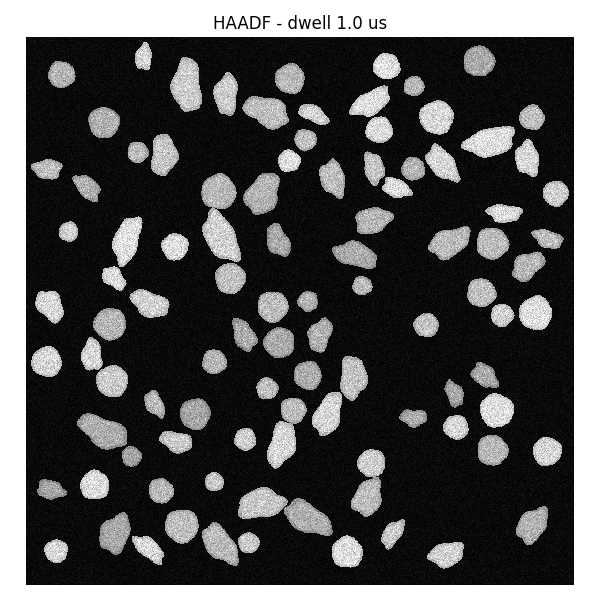

In [7]:
microscope.set_fov(10*1e-9)
microscope.set_image_shift([0e-9, 0])
data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

### Send to Segmentation device on workstation

In [8]:
results = seg.segment(data_key)


In [9]:
results

'segmentation_c3c190cec2db48d88e259797408b6346'

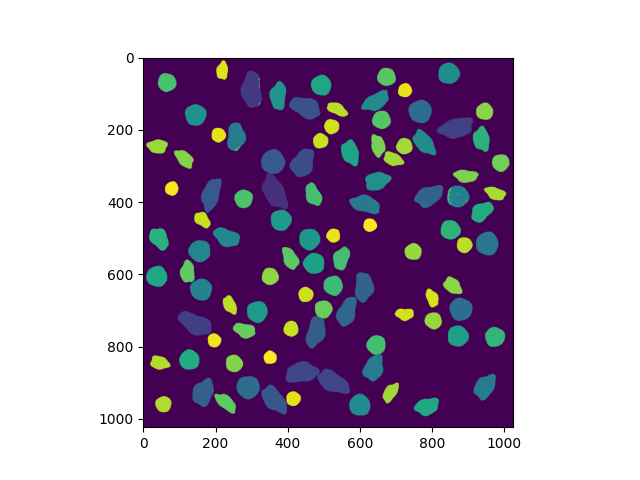

In [11]:
mask = client[results].read()

plt.figure()
plt.imshow(mask)

### Acquire multiple detectors


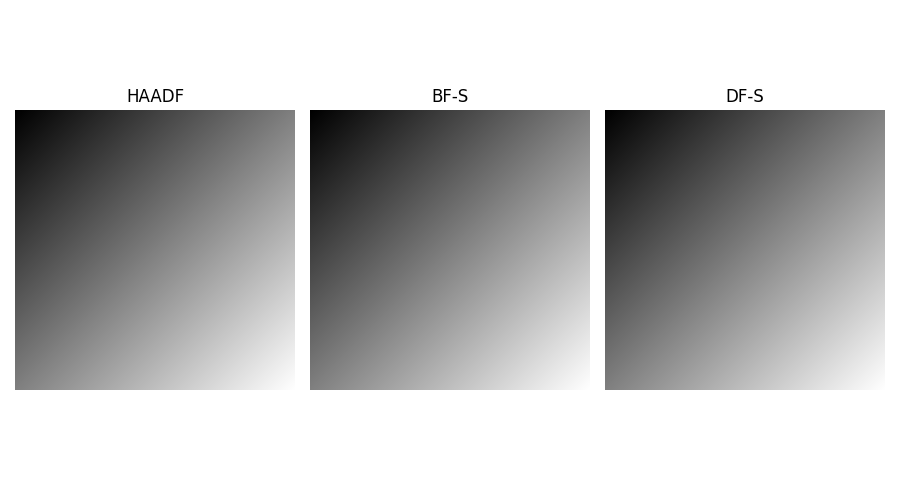

In [9]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
detector_list = ["HAADF", "BF-S", "DF-S"]
key = microscope.acquire_scanned_image(["HAADF", "BF-S", "DF-S"])
dset = client[key]["image"]

images = []
names = []
for detector_name in dset:
    image = dset[detector_name].read()
    images.append(image)
    names.append(detector_name)

fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 5))
for ax, im, n in zip(axes, images, names):
    ax.imshow(im, cmap="gray")
    ax.set_title(str(n).upper())
    ax.axis("off")
fig.tight_layout()


## if using tiff as output fomrat(AutoScript Native) i.e scan.output_format = ".tiff"

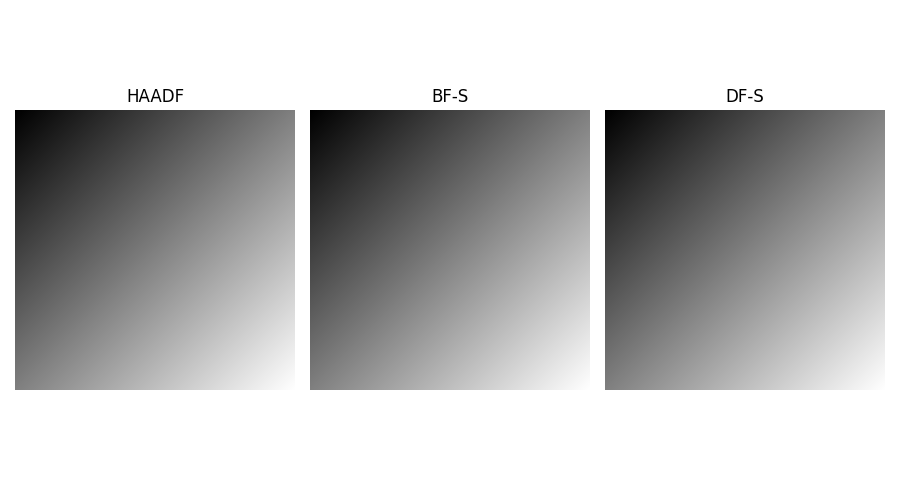

In [10]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
scan.output_format = ".tiff"

detector_list = ["HAADF", "BF-S", "DF-S"]
key = microscope.acquire_scanned_image(detector_list)   # returns the shared stem, e.g. "stem_image_20260604T123909936109"

images = []
names = []
for det in detector_list:
    node = client[f"{key}_{det.upper()}.tiff"]   # one TIFF per detector
    images.append(node.read())                   # read the image array directly
    names.append(det)

fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 5))
for ax, im, n in zip(axes, images, names):
    ax.imshow(im, cmap="gray")
    ax.set_title(str(n).upper())
    ax.axis("off")
fig.tight_layout()

### Acquire a cropped rectangle scan


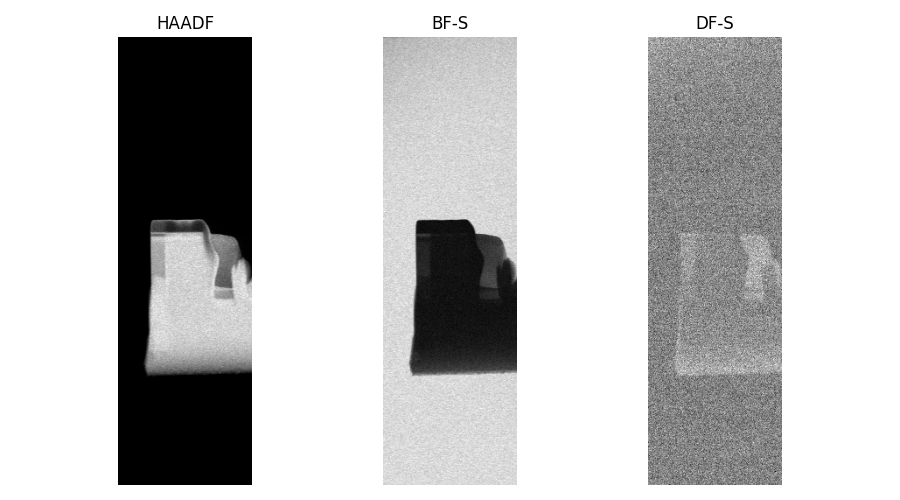

In [9]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.output_format = ".tiff"
scan.scan_region = [0, 0, .3, 1]


detector_list = ["HAADF", "BF-S", "DF-S"]
key = microscope.acquire_scanned_image(detector_list)   # returns the shared stem, e.g. "stem_image_20260604T123909936109"

images = []
names = []
for det in detector_list:
    node = client[f"{key}_{det.upper()}.tiff"]   # one TIFF per detector
    images.append(node.read())                   # read the image array directly
    names.append(det)

fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 5))
for ax, im, n in zip(axes, images, names):
    ax.imshow(im, cmap="gray")
    ax.set_title(str(n).upper())
    ax.axis("off")
fig.tight_layout()

## Lets do some acquisiton on the Camera now to get some diffraction patterns.
**Make sure to check the screen current(less than 100 pico Amps should be good)**

In [ ]:
camera.camera_detector = "BM-Ceta"  # use "Flucam" to acquire from Flucam
camera.imsize = 1024
camera.exposure_time = 0.5
camera.readout_area = "Half"
camera.frame_combining = 1
camera.output_format = ".h5"

camera_key = microscope.acquire_camera_image()
camera_node = client[camera_key]["image"]
camera_image = camera_node.read()
camera_metadata = dict(camera_node.metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(camera_image, cmap="gray", interpolation="none")
ax.set_title(
    f"{camera.camera_detector} - exposure {camera.exposure_time:.3f} s"
)
ax.axis("off")
plt.tight_layout()

print("Camera key:", camera_key)
print("Image shape:", camera_image.shape)
pprint(camera_metadata)

### Optional: save the camera image as AutoScript-native TIFF


In [ ]:
camera.output_format = ".tiff"
camera_stem = microscope.acquire_camera_image()

camera_tiff_key = f"{camera_stem}_{camera.camera_detector}.tiff"
camera_tiff = client[camera_tiff_key].read()

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(camera_tiff, cmap="gray", interpolation="none")
ax.set_title(camera_tiff_key)
ax.axis("off")
plt.tight_layout()

# Restore the default for subsequent acquisitions.
camera.output_format = ".h5"